# Quality Assessment
Now it's your turn. Follow the steps on the platform and use what you've learnt to see how reliable the data is.

In [5]:
import pandas as pd
import seaborn as sns

Load our cleaned DataFrames

In [6]:
# orders_cl.csv
o_cl = pd.read_csv('../data/cleaned_orders_file.csv')
# orderlines_cl.csv
ol_cl = pd.read_csv('../data/orderlines_full.csv')
# products_cl.csv
p_cl = pd.read_csv('../data/cleaned_products_file.csv')
# brands
b_cl = pd.read_csv('../data/cleaned_brands_file.csv')

In [7]:
p_cl.info()

<class 'pandas.DataFrame'>
RangeIndex: 10104 entries, 0 to 10103
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   sku       10104 non-null  str    
 1   name      10104 non-null  str    
 2   desc      10104 non-null  str    
 3   price     10104 non-null  float64
 4   in_stock  10104 non-null  int64  
 5   type      10104 non-null  str    
dtypes: float64(1), int64(1), str(4)
memory usage: 473.8 KB


## 1.&nbsp; Define Pandas display format

In [8]:
#pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.set_option('display.max_rows', 1000)
orders_q = o_cl.copy()
orderlines_q = ol_cl.copy()
products_q = p_cl.copy()
brands_q = b_cl.copy()

orders_q.created_date = pd.to_datetime(orders_q.created_date)
orderlines_q.date = pd.to_datetime(orderlines_q.date)

## 2.&nbsp; Exclude unwanted orders

In [9]:
orders_q.state.value_counts()

state
Shopping Basket    117809
Completed           46605
Place Order         40883
Pending             14374
Cancelled            7233
Name: count, dtype: int64

In [10]:
orders_q = orders_q.loc[orders_q.state == 'Completed', :]
orders_q.order_id.nunique()

46605

## 3.&nbsp; Exclude orders with unknown products


In [11]:
orders_orderlines = orders_q.merge(orderlines_q, how="inner", left_on="order_id", right_on="id_order")
orders_orderlines.duplicated('id_order').sum() #14429
mask_id_order = orders_orderlines.id_order.unique()
mask_order_id = orders_orderlines["order_id"].unique()
(mask_id_order == mask_order_id).all()
order_ids = mask_id_order

In [12]:
orders_q = orders_q.loc[orders_q["order_id"].isin(order_ids), :]
orderlines_q = orderlines_q.loc[orderlines_q["id_order"].isin(order_ids), :]
# check the result:
orders_q["order_id"].nunique(), orderlines_q["id_order"].nunique()

(46560, 46560)

In [13]:
orderlines_products = orderlines_q.merge(products_q, how="left", on = "sku")[["id_order","sku","name" ]]
#and check 
orderlines_products.sample(10)

,id_order,sku,name
12659,352972,SAT0054,Satechi Hub Multiport USB-C 4K HDMI Space Gray
41887,452990,OTT0147,Otterbox iPhone Case Symmetry 8 Plus / 7 Plus ...
55948,503826,CRU0060,Crucial MX500 250GB SSD 7mm
15452,363403,OWC0087,OWC Bluetooth module shielding shielding kit B...
40885,446264,WAC0173,Education - Wacom Intuos Creative Art Pen & To...
5890,316116,MAC0121,Macally Snap-on Case iPhone 6 / 6S metallic red
8793,324610,HTE0010,BOBO Hyper VR Virtual Reality Glasses White Z4
12746,353301,APP0930,Apple Mac mini Core i7 3GHz | 16GB RAM | 1TB F...
60939,521873,MAC0144,Macally Lampcharge Lamp with 4 USB ports
27650,406366,CRU0052-2,Crucial memory Mac 16GB (2x8GB) SO-DIMM DDR4 2...


In [14]:
# and then check again for NaNs:
orderlines_products.name.isna().value_counts() # 975
# we make a mask 975 (  966 are unique) 
orders_to_delete = orderlines_products.loc[orderlines_products.name.isna(), "id_order"]#.unique

In [15]:
# we use the mask to delete orders with order_id, which are NOT in the list to delete!!!
orders_q = orders_q.loc[~orders_q.order_id.isin(orders_to_delete),:]
# we use the mask to delete orderlines with id_order, which are NOT in the list to delete!!!
orderlines_q = orderlines_q.loc[~orderlines_q.id_order.isin(orders_to_delete),:]
# and if we are lucki and did everything right... we should have same number of unique ids in both df 
orders_q["order_id"].nunique(), orderlines_q["id_order"].nunique()

(45363, 45363)

## 4.&nbsp; Explore the revenue from different tables

#### Step 1:
Create the `unit_price_total` as `orderlines.unit_price` * `orderlines.product_quantity`

In [16]:
# rename the df again, f means final (very optimistic) 
orders_f = orders_q.copy()
orderlines_f = orderlines_q.copy()
# create the new column
orderlines_f["unit_price_total"] = orderlines_f["product_quantity"] * orderlines_f["unit_price"]
# and chek the result
orderlines_f

,id,id_order,product_id,product_quantity,sku,unit_price,date,unit_price_total
7,1119116,299545,0,1,OWC0100,47.49,2017-01-01 01:46:16,47.49
8,1119119,299546,0,1,IOT0014,18.99,2017-01-01 01:50:34,18.99
9,1119120,295347,0,1,APP0700,72.19,2017-01-01 01:54:11,72.19
11,1119126,299549,0,1,PAC0929,2565.99,2017-01-01 02:07:42,2565.99
18,1119134,299556,0,1,CRU0039-A,60.90,2017-01-01 02:20:14,60.90
...,...,...,...,...,...,...,...,...
293599,1649474,525664,0,1,TUC0207,16.52,2018-03-14 11:45:05,16.52
293616,1649512,527070,0,2,APP0698,9.99,2018-03-14 11:49:01,19.98
293621,1649522,527074,0,2,APP0698,9.99,2018-03-14 11:49:36,19.98
293644,1649565,527096,0,3,APP0698,9.99,2018-03-14 11:54:35,29.97


#### Step 2:
Group by `id_order`, summarising by the sum of `unit_price_total`

In [17]:
# set unit_price_total as upt 
upt_id_order = orderlines_f.groupby('id_order', as_index = False)['unit_price_total'].sum()
# I prefer to use the 'id_order' as index, but if would like to keep both, set as_index = False


### What is the average difference between `total_paid` and `unit_price_total`?

In [18]:
# now merge both df as new 'profit'
profit = orders_f.merge(upt_id_order, left_on='order_id', right_on='id_order')
# and make the new column 'difference'
profit['difference'] = profit['total_paid'] - profit ['unit_price_total']
# finally look on the result
profit['difference'].sort_values(ascending=True)
# or better use discribe:
profit.difference.describe()

count    45363.000000
mean         4.267516
std         25.038549
min       -165.000000
25%          0.000000
50%          4.990000
75%          6.990000
max       3984.990000
Name: difference, dtype: float64

### What is the distribution of these differences?

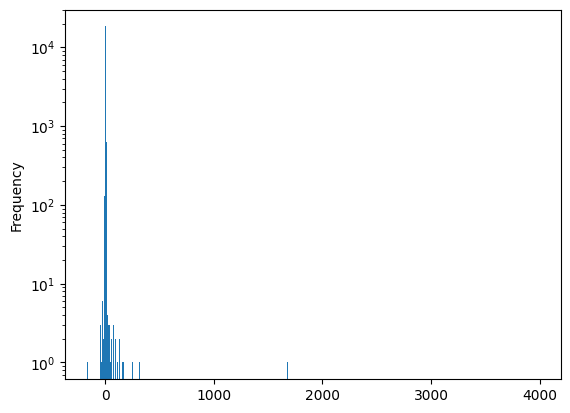

In [19]:
profit.difference.plot(kind='hist', bins=1000)
import matplotlib.pyplot as plt

plt.yscale('log')

# You can play with the plot, but results look really strange

#plt.xlim(-50, 50)
#.hist(bins= 50, figsize=(8,6));


### Can all the differences be explained by shipping costs? If not, what are other plausible explanations?

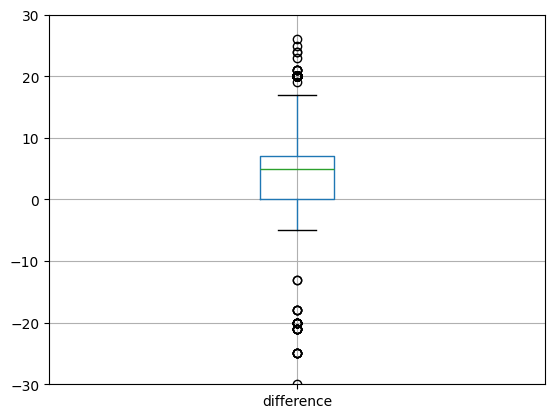

In [20]:
# We know this rule from the boxplot
import matplotlib.pyplot as plt

ax = profit.boxplot("difference");
ax.set_ylim(-30, +30)

# if you are brave enough you can try with different settings...
#ax.set_ylim(-300, +3000)

plt.show()

In [21]:
# we believe it's all about perspective
# smile and wave and calculate the quartiles
Q1 = profit["difference"].quantile(0.25)
Q3 = profit["difference"].quantile(0.75)
# now calculate IQR
IQR = Q3-Q1
# and finally the whiskers 
low = Q1 - 1.5*IQR
high = Q3 + 1.5*IQR
# and now filter the DataFrame to include only "non-outliers"
profit_f = profit.loc[
    (profit["difference"] >= (Q1 - 1.5*IQR))
    &
    (profit["difference"] <= (Q3 + 1.5*IQR))
    ,
    :]
profit_f.shape

(44637, 7)

### If there are differences that you can’t explain: what should you do with these orders?

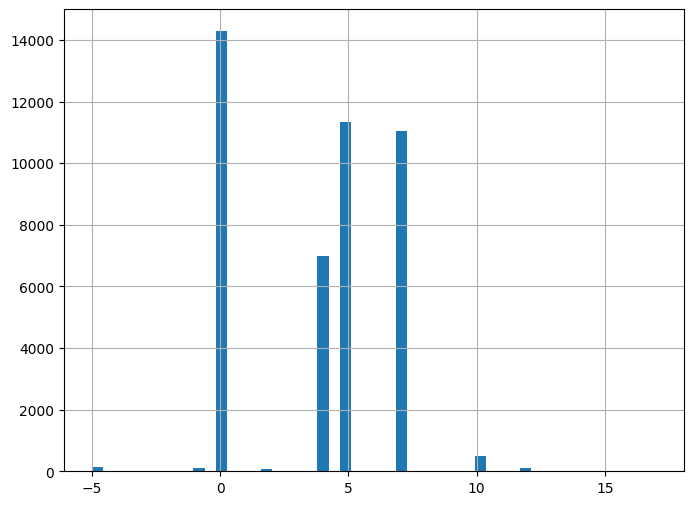

In [22]:
# clear stuff, we delete them, now our histogram looks amaizing!
profit_f.difference.hist(bins= 50, figsize=(8,6));

<Axes: >

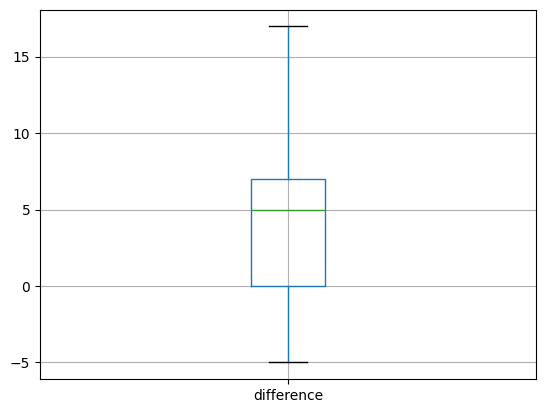

In [23]:
# and our boxplot as well!
profit_f.boxplot("difference")

In [24]:
# lets check again and make sure we have the data saved
# set up the mask
normal_profit_list = profit_f["order_id"]
# rewrite the orders_df without the outliers
orders_q = orders_q.loc[orders_q["order_id"].isin(normal_profit_list), :]
# rewrite the orderlines_df without the outliers
orderlines_q = orderlines_q.loc[orderlines_q["id_order"].isin(normal_profit_list), :]
# doublecheck they still match
orders_q["order_id"].nunique(), orderlines_q["id_order"].nunique()

(44637, 44637)

In [25]:
# one more time, we can save the df to csv
#orders_q.to_csv('../data/orders_ext_rev2.csv')
#orderlines_q.to_csv('../data/orederlines_ext_rev2.csv')

## 5.&nbsp; Become confident about your dataset

Let's hear your thoughts about what you discovered.

In [26]:
# your thoughts & code here

Do not forget to download your quality controlled DataFrames

In [27]:
#from google.colab import files

#orders_quality_controlled.to_csv("orders_qu.csv", index=False)
#files.download("orders_qu.csv")

#orderlines_quality_controlled.to_csv("orderlines_qu.csv", index=False)
#files.download("orderlines_qu.csv")

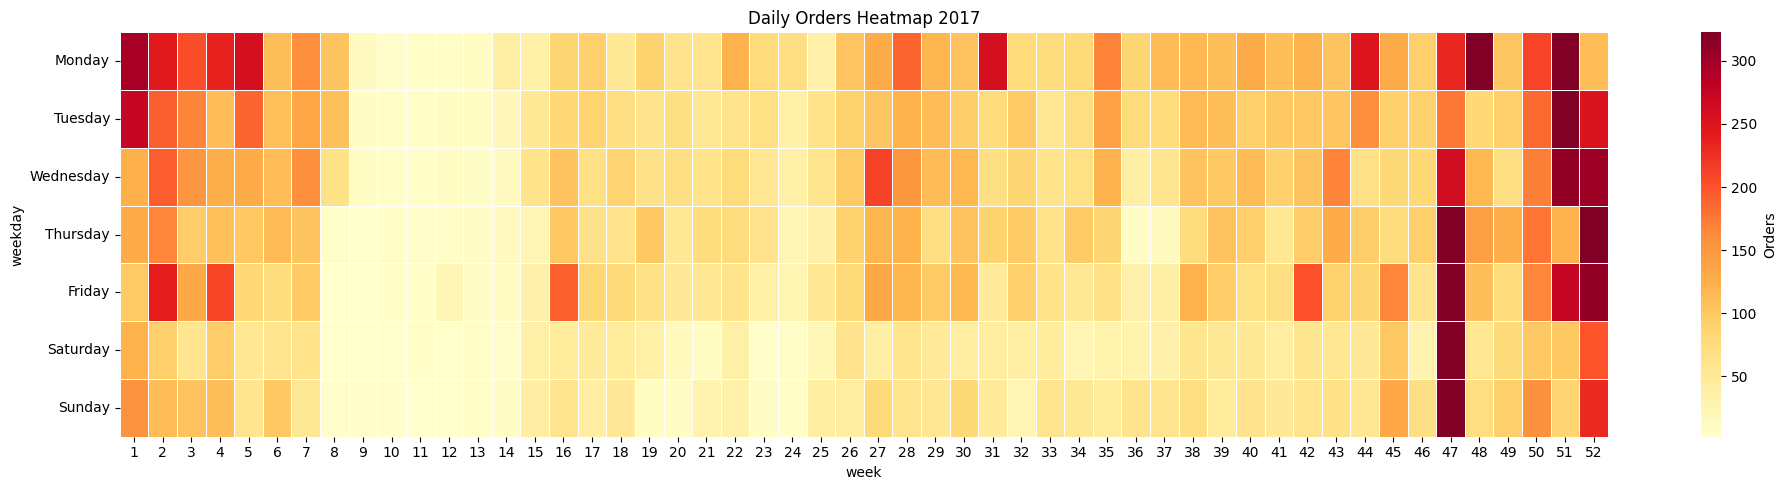

In [28]:
daily = orders_q.resample('D', on='created_date').count()['order_id']

df_heat = pd.DataFrame({'count': daily})
df_heat['weekday'] = daily.index.day_name()
df_heat['week'] = daily.index.isocalendar().week.astype(int)
df_heat['year'] = daily.index.year

df_heat = df_heat[df_heat['year'] == 2017]  # ← filter here

pivot = df_heat.pivot_table(index='weekday', columns='week', values='count', aggfunc='sum')
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = pivot.reindex(weekday_order)

plt.figure(figsize=(20, 5))
#sns.heatmap(pivot, cmap='tab20', linewidths=0.5, cbar_kws={'label': 'Orders'})
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.5, 
            robust=True,  # ignores outliers for color scaling
            cbar_kws={'label': 'Orders'})
plt.title('Daily Orders Heatmap 2017')
plt.tight_layout()
plt.show()

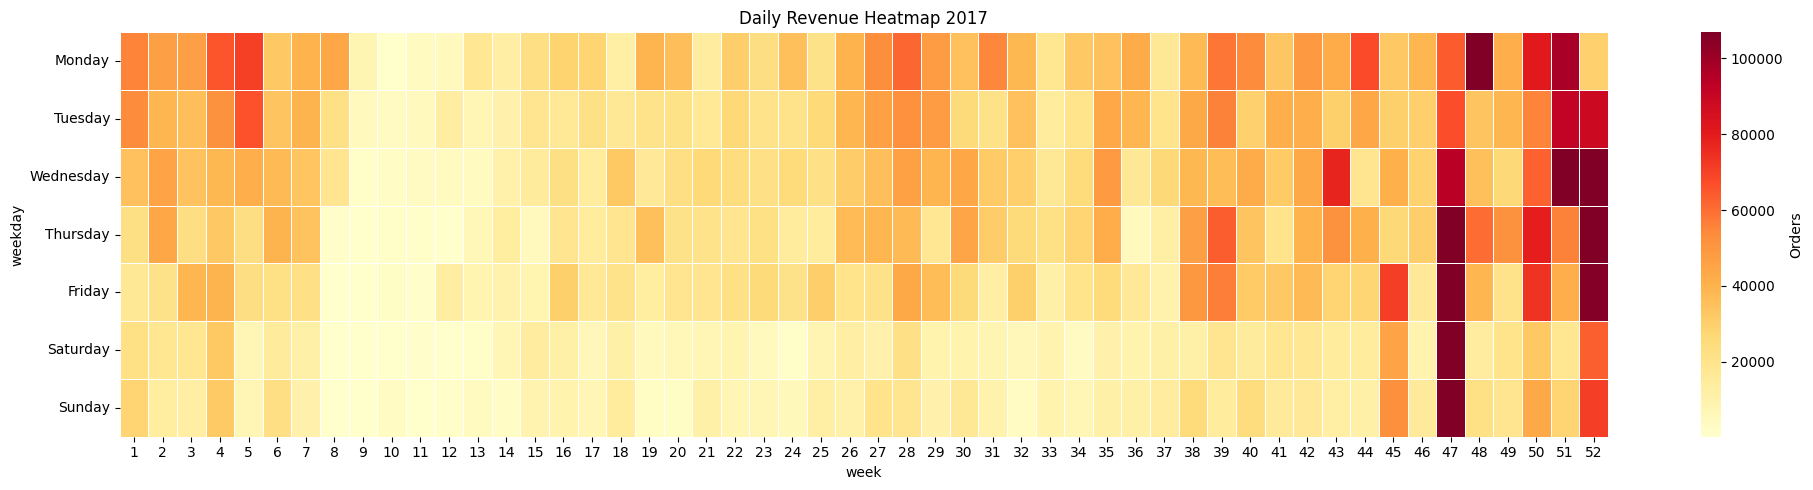

In [29]:
daily = orders_q.resample('D', on='created_date').sum()['total_paid']

df_heat2 = pd.DataFrame({'sum': daily})
df_heat2['weekday'] = daily.index.day_name()
df_heat2['week'] = daily.index.isocalendar().week.astype(int)
df_heat2['year'] = daily.index.year

df_heat2 = df_heat2[df_heat2['year'] == 2017]  # ← filter here

pivot = df_heat2.pivot_table(index='weekday', columns='week', values='sum', aggfunc='sum')
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = pivot.reindex(weekday_order)

plt.figure(figsize=(20, 5))
#sns.heatmap(pivot, cmap='tab20', linewidths=0.5, cbar_kws={'label': 'Orders'})
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.5, 
            robust=True,  # ignores outliers for color scaling
            cbar_kws={'label': 'Orders'})
plt.title('Daily Revenue Heatmap 2017')
plt.tight_layout()
plt.show()

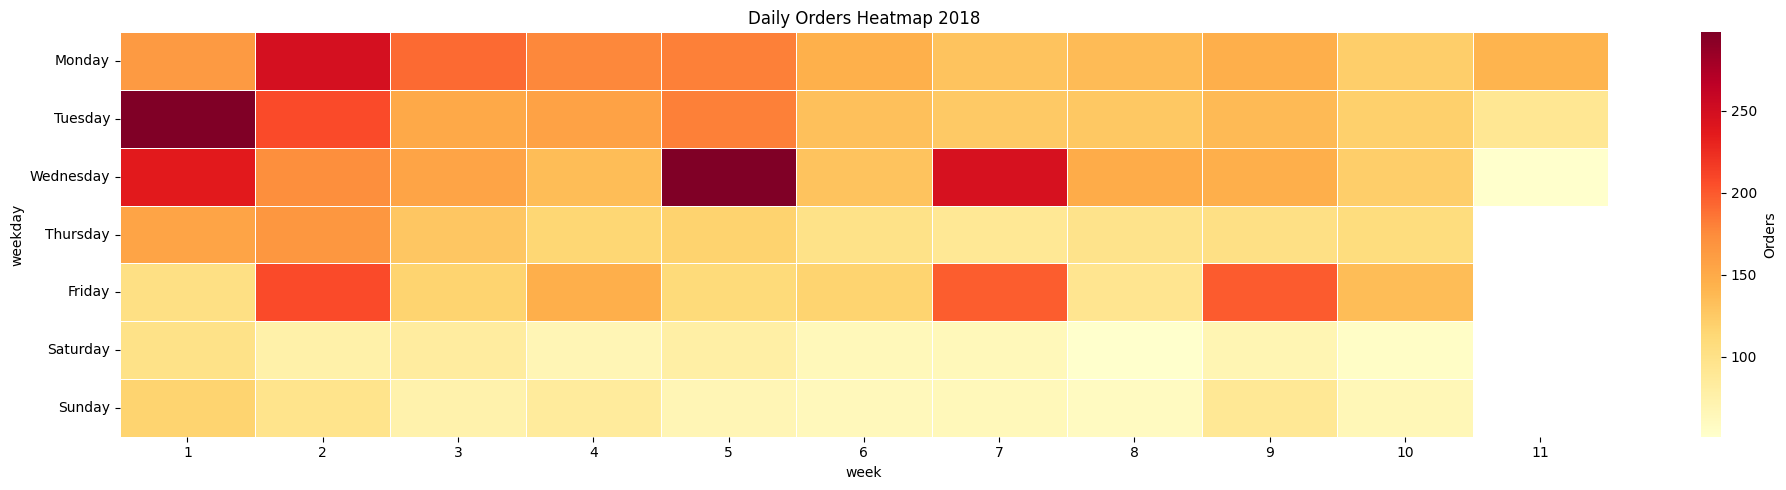

In [30]:
daily = orders_q.resample('D', on='created_date').count()['order_id']

df_heat = pd.DataFrame({'count': daily})
df_heat['weekday'] = daily.index.day_name()
df_heat['week'] = daily.index.isocalendar().week.astype(int)
df_heat['year'] = daily.index.year

df_heat = df_heat[df_heat['year'] == 2018]  # ← filter here

pivot = df_heat.pivot_table(index='weekday', columns='week', values='count', aggfunc='sum')
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = pivot.reindex(weekday_order)

plt.figure(figsize=(20, 5))
#sns.heatmap(pivot, cmap='tab20', linewidths=0.5, cbar_kws={'label': 'Orders'})
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.5, 
            robust=True,  # ignores outliers for color scaling
            cbar_kws={'label': 'Orders'})
plt.title('Daily Orders Heatmap 2018')
plt.tight_layout()
plt.show()

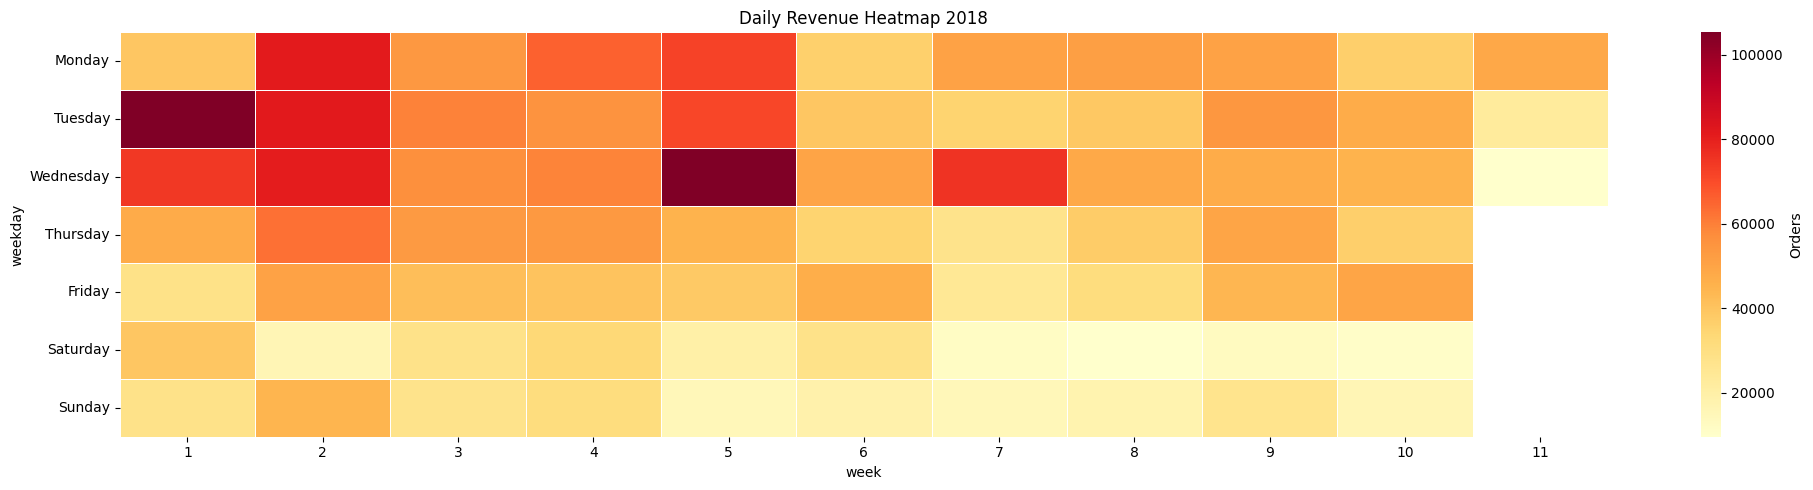

In [31]:
daily = orders_q.resample('D', on='created_date').sum()['total_paid']

df_heat2 = pd.DataFrame({'sum': daily})
df_heat2['weekday'] = daily.index.day_name()
df_heat2['week'] = daily.index.isocalendar().week.astype(int)
df_heat2['year'] = daily.index.year

df_heat2 = df_heat2[df_heat2['year'] == 2018]  # ← filter here

pivot = df_heat2.pivot_table(index='weekday', columns='week', values='sum', aggfunc='sum')
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = pivot.reindex(weekday_order)

plt.figure(figsize=(20, 5))
#sns.heatmap(pivot, cmap='tab20', linewidths=0.5, cbar_kws={'label': 'Orders'})
sns.heatmap(pivot,  cmap='YlOrRd', linewidths=0.5, # annot=True,
            robust=True,  # ignores outliers for color scaling
            cbar_kws={'label': 'Orders'})
plt.title('Daily Revenue Heatmap 2018')
plt.tight_layout()
plt.show()